In [3]:
import sys, site
print("sys.executable:", sys.executable)
print("sys.version:", sys.version)
print("sys.path (first lines):")
for p in sys.path[:6]:
    print(" ", p)
print("\nsite.getsitepackages (if available):")
try:
    print(site.getsitepackages())
except Exception as e:
    print(" ", e)


sys.executable: C:\ProgramData\ anaconda3\python.exe
sys.version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
sys.path (first lines):
  C:\ProgramData\ anaconda3\python313.zip
  C:\ProgramData\ anaconda3\DLLs
  C:\ProgramData\ anaconda3\Lib
  C:\ProgramData\ anaconda3
  
  C:\Users\mites\AppData\Roaming\Python\Python313\site-packages

site.getsitepackages (if available):
['C:\\ProgramData\\ anaconda3', 'C:\\ProgramData\\ anaconda3\\Lib\\site-packages']


In [1]:
# Auto-fix: try installing/importing catboost; fallback to LightGBM if install fails.
import sys, subprocess, importlib, os, warnings
warnings.filterwarnings("ignore")

def try_import(pkg):
    try:
        return importlib.import_module(pkg)
    except Exception:
        return None

def run(cmd_list):
    print("Running:", " ".join(cmd_list))
    return subprocess.run(cmd_list, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

# 1) Try direct import first
catboost = try_import("catboost")
if catboost:
    print("CatBoost already installed:", getattr(catboost, "__version__", "unknown"))
else:
    print("CatBoost not found — attempting to install...")

    # Try pip install --user
    cmds_to_try = [
        [sys.executable, "-m", "pip", "install", "--user", "--upgrade", "pip", "setuptools", "wheel"],
        [sys.executable, "-m", "pip", "install", "--user", "catboost"],
        [sys.executable, "-m", "pip", "install", "--user", "--upgrade", "catboost"],
        [sys.executable, "-m", "pip", "install", "--no-cache-dir", "catboost"]
    ]

    installed = False
    for cmd in cmds_to_try:
        res = run(cmd)
        print(res.stdout)
        if res.returncode == 0:
            # try import
            catboost = try_import("catboost")
            if catboost:
                print("Successfully installed CatBoost:", getattr(catboost, "__version__", "unknown"))
                installed = True
                break
        else:
            # show the last line of stderr to help debugging (but keep it short)
            err = res.stderr.strip().splitlines()[-3:]
            print("Install failed (summary):")
            for line in err:
                print(" ", line)

    if not installed:
        print("\nCould not install CatBoost in this environment. Will attempt LightGBM fallback.\n"
              "If you are on a restricted platform (Coursera, campus server), consider using Google Colab:\n"
              "  1) Go to https://colab.research.google.com\n  2) Upload your notebook or dataset\n  3) Run: !pip install catboost\n")

# 2) If CatBoost not available, try LightGBM
lgb = try_import("lightgbm")
if not catboost and not lgb:
    print("LightGBM not found — attempting to install LightGBM...")
    res = run([sys.executable, "-m", "pip", "install", "--user", "lightgbm"])
    print(res.stdout)
    if res.returncode == 0:
        lgb = try_import("lightgbm")
        if lgb:
            print("LightGBM installed:", getattr(lgb, "__version__", "unknown"))
    else:
        print("LightGBM install failed. Summary of error:")
        print(res.stderr.splitlines()[-6:])

# 3) Now provide a helper function to train (uses CatBoost if available, else LightGBM)
def train_model(df=None, target_col="Churn", id_cols=None, test_size=0.2, random_state=42):
    """
    If df is None, tries to load /mnt/data/telecom_churn.csv or prompts to set DATA_PATH.
    Trains CatBoost if available otherwise LightGBM. Returns fitted model and (X_test,y_test).
    """
    from sklearn.model_selection import train_test_split
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

    if id_cols is None:
        id_cols = []

    # Load df if not passed
    if df is None:
        default_path = "/mnt/data/telecom_churn.csv"
        if os.path.exists(default_path):
            print("Loading dataset from", default_path)
            import pandas as pd
            df = pd.read_csv(default_path)
        else:
            raise FileNotFoundError("No dataframe provided and default path not found. "
                                    "Please set df parameter or place CSV at /mnt/data/telecom_churn.csv")

    import pandas as pd
    # basic cleanup
    df = df.copy()
    df = df.drop(columns=[c for c in id_cols if c in df.columns], errors="ignore")
    if target_col not in df.columns:
        raise KeyError(f"Target column '{target_col}' not found in dataframe. Please set target_col correctly.")

    # convert target to binary numeric if needed
    if df[target_col].dtype == object or df[target_col].dtype.name == 'category':
        df[target_col], _ = pd.factorize(df[target_col])

    X = df.drop(columns=[target_col])
    y = df[target_col].astype(int)

    # detect categorical columns
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = X.select_dtypes(include=[float, int]).columns.tolist()

    # impute num, fill cat
    if len(num_cols) > 0:
        num_imp = SimpleImputer(strategy="median")
        X[num_cols] = num_imp.fit_transform(X[num_cols])
    if len(cat_cols) > 0:
        X[cat_cols] = X[cat_cols].fillna("Missing")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,
                                                        random_state=random_state, stratify=y)

    if catboost:
        print("Training with CatBoost...")
        from catboost import CatBoostClassifier, Pool
        cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_cols] if cat_cols else []
        train_pool = Pool(X_train, label=y_train, cat_features=cat_feature_indices)
        eval_pool  = Pool(X_test,  label=y_test,  cat_features=cat_feature_indices)

        model = CatBoostClassifier(
            iterations=1000,
            learning_rate=0.05,
            depth=6,
            eval_metric="AUC",
            random_seed=random_state,
            logging_level="Silent",
            od_type="Iter",
            od_wait=50,
            task_type="CPU"
        )
        model.fit(train_pool, eval_set=eval_pool, use_best_model=True, verbose=100)

        yproba = model.predict_proba(X_test)[:,1]
        ypred = (yproba >= 0.5).astype(int)

    elif lgb:
        print("Training with LightGBM (fallback)...")
        from lightgbm import LGBMClassifier
        # convert categorical columns to category dtype for LightGBM
        for c in cat_cols:
            X_train[c] = X_train[c].astype("category")
            X_test[c]  = X_test[c].astype("category")

        model = LGBMClassifier(
            n_estimators=1000,
            learning_rate=0.05,
            num_leaves=31,
            random_state=random_state
        )
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=50, verbose=100)

        yproba = model.predict_proba(X_test)[:,1]
        ypred = (yproba >= 0.5).astype(int)
    else:
        raise RuntimeError("Neither CatBoost nor LightGBM are available. "
                           "Please run this notebook on an environment that allows package installs or use Google Colab.")

    # evaluation summary
    print("\nEval summary:")
    print("  Accuracy:", accuracy_score(y_test, ypred))
    try:
        print("  ROC AUC:", roc_auc_score(y_test, yproba))
    except Exception:
        pass
    print("\nClassification report:\n", classification_report(y_test, ypred))
    return model, X_test, y_test

# Done: notify user how to call
print("\nHelper ready. To train, call (example):")
print("  model, X_test, y_test = train_model(df=df, target_col='Churn')  # or omit df if /mnt/data/telecom_churn.csv exists")
print("\nIf you still face 'Access is denied' when pip installing, your environment blocks installs. "
      "In that case, open the notebook in Google Colab (colab.research.google.com) and run: `!pip install catboost` first.")


CatBoost already installed: 1.2.8

Helper ready. To train, call (example):
  model, X_test, y_test = train_model(df=df, target_col='Churn')  # or omit df if /mnt/data/telecom_churn.csv exists

If you still face 'Access is denied' when pip installing, your environment blocks installs. In that case, open the notebook in Google Colab (colab.research.google.com) and run: `!pip install catboost` first.


In [7]:
# run in a notebook cell
import sys
!"{sys.executable}" -m pip install --upgrade --force-reinstall --no-cache-dir catboost


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/102.4 MB ? eta -:--:--
   ---------------------------------------- 1.0/102.4 MB 3.1 MB/s eta 0:00:33
    --------------------------------------- 1.8/102.4 MB 3.5 MB/s eta 0:00:30
   - -------------------------------------- 2.9/102.4 MB 4.0 MB/s eta 0:00:26
   - -------------------------------------- 4.2/102.4 MB 4.5 MB/s eta 0:00:22
   -- ------------------------------------- 5.5/102.4 MB 4.9 MB/s eta 0:00:20
   -- ------------------------------------- 7.1/102.4 MB 5.3 MB/s eta 0:00:19
   --- ------------------------------------ 8.9/102.4 MB 5.8 MB/s eta 0:00:17
   ---- ----------------------------------- 11.0/102.4 MB 6.3 MB/s eta 0:00:15
   ----- ---------------------------------- 13.1/102.4 MB 6.7 MB/s eta 0:00:14
   ------ --------------------------------- 15.5/102.4 MB 7.1 MB/s eta 0:00:

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.3.4 which is incompatible.
streamlit 1.45.1 requires packaging<25,>=20, but you have packaging 25.0 which is incompatible.
streamlit 1.45.1 requires pillow<12,>=7.1.0, but you have pillow 12.0.0 which is incompatible.


In [9]:
import sys, site
print("sys.executable:", sys.executable)
print("sys.version:", sys.version)
print("sys.path (first lines):")
for p in sys.path[:6]:
    print(" ", p)
print("\nsite.getsitepackages (if available):")
try:
    print(site.getsitepackages())
except Exception as e:
    print(" ", e)


sys.executable: C:\ProgramData\ anaconda3\python.exe
sys.version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
sys.path (first lines):
  C:\ProgramData\ anaconda3\python313.zip
  C:\ProgramData\ anaconda3\DLLs
  C:\ProgramData\ anaconda3\Lib
  C:\ProgramData\ anaconda3
  
  C:\Users\mites\AppData\Roaming\Python\Python313\site-packages

site.getsitepackages (if available):
['C:\\ProgramData\\ anaconda3', 'C:\\ProgramData\\ anaconda3\\Lib\\site-packages']


In [11]:
# run in a notebook cell
import sys
!"{sys.executable}" -m pip install --upgrade --force-reinstall --no-cache-dir catboost


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 1.0/102.4 MB 6.7 MB/s eta 0:00:16
   - -------------------------------------- 2.6/102.4 MB 6.8 MB/s eta 0:00:15
   - -------------------------------------- 4.5/102.4 MB 7.5 MB/s eta 0:00:14
   -- ------------------------------------- 6.6/102.4 MB 8.1 MB/s eta 0:00:12
   --- ------------------------------------ 8.7/102.4 MB 8.6 MB/s eta 0:00:11
   ---- ----------------------------------- 10.7/102.4 MB 8.9 MB/s eta 0:00:11
   ----- ---------------------------------- 13.1/102.4 MB 9.2 MB/s eta 0:00:10
   ----- ---------------------------------- 15.2/102.4 MB 9.4 MB/s eta 0:00:10
   ------ --------------------------------- 17.6/102.4 MB 9.6 MB/s eta 0:00:09
   ------- -------------------------------- 19.7/102.4 MB 9.7 MB/s eta 0:00:09
   -------- ------------------------------- 22.0/102.4 MB 9.8 MB/s

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.3.4 which is incompatible.
streamlit 1.45.1 requires packaging<25,>=20, but you have packaging 25.0 which is incompatible.
streamlit 1.45.1 requires pillow<12,>=7.1.0, but you have pillow 12.0.0 which is incompatible.


In [12]:
import catboost
print("CatBoost", catboost.__version__)


CatBoost 1.2.8


In [14]:
# from inside notebook (same interpreter as kernel)
import importlib, pkgutil, sys
print(sys.executable)
spec = importlib.util.find_spec("catboost")
print("catboost spec:", spec)
import pkgutil
print("Installed packages sample:", [p.name for p in pkgutil.iter_modules()][:30])


C:\ProgramData\ anaconda3\python.exe
catboost spec: ModuleSpec(name='catboost', loader=<_frozen_importlib_external.SourceFileLoader object at 0x000002A71C2B1A90>, origin='C:\\Users\\mites\\AppData\\Roaming\\Python\\Python313\\site-packages\\catboost\\__init__.py', submodule_search_locations=['C:\\Users\\mites\\AppData\\Roaming\\Python\\Python313\\site-packages\\catboost'])
Installed packages sample: ['_asyncio', '_bz2', '_ctypes', '_ctypes_test', '_decimal', '_elementtree', '_hashlib', '_lzma', '_multiprocessing', '_overlapped', '_queue', '_socket', '_sqlite3', '_ssl', '_testbuffer', '_testcapi', '_testclinic', '_testclinic_limited', '_testconsole', '_testimportmultiple', '_testinternalcapi', '_testlimitedcapi', '_testmultiphase', '_testsinglephase', '_tkinter', '_uuid', '_wmi', '_zoneinfo', 'pyexpat', 'select']


In [21]:
DATA_PATH = "telecom_churn.csv"


In [22]:
import os
import pandas as pd

DATA_PATH = "telecom_churn.csv"

if not os.path.exists(DATA_PATH):
    print("File not found, please upload it or correct the path.")
else:
    df = pd.read_csv(DATA_PATH)
    print("Loaded:", df.shape)


File not found, please upload it or correct the path.


In [23]:
DATA_PATH = "data/telecom_churn.csv"


In [24]:
import pandas as pd

data = {
    'customerID': ['001', '002', '003', '004', '005'],
    'gender': ['Male', 'Female', 'Female', 'Male', 'Male'],
    'SeniorCitizen': [0, 1, 0, 0, 1],
    'tenure': [1, 34, 2, 45, 5],
    'MonthlyCharges': [29.85, 56.95, 53.85, 42.30, 70.70],
    'Churn': ['No', 'Yes', 'No', 'No', 'Yes']
}

df = pd.DataFrame(data)
df.to_csv("telecom_churn.csv", index=False)
print("Sample dataset created as telecom_churn.csv")


Sample dataset created as telecom_churn.csv


In [29]:
from sklearn.model_selection import train_test_split

TEST_SIZE = max(0.2, 2 / len(y))  # ensure at least 2 samples in test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)


In [30]:
test_size = 0.25


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)


In [32]:
from catboost import Pool

cat_features = list(X.select_dtypes(include=["object", "category"]).columns)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)


In [33]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_state=RANDOM_STATE,
    verbose=100
)

model.fit(train_pool, eval_set=test_pool, use_best_model=True)


0:	learn: 1.0000000	test: 0.0000000	best: 0.0000000 (0)	total: 147ms	remaining: 1m 13s
100:	learn: 1.0000000	test: 0.0000000	best: 1.0000000 (3)	total: 219ms	remaining: 864ms
200:	learn: 1.0000000	test: 0.0000000	best: 1.0000000 (3)	total: 292ms	remaining: 434ms
300:	learn: 1.0000000	test: 0.0000000	best: 1.0000000 (3)	total: 369ms	remaining: 244ms
400:	learn: 1.0000000	test: 0.0000000	best: 1.0000000 (3)	total: 447ms	remaining: 110ms
499:	learn: 1.0000000	test: 0.0000000	best: 1.0000000 (3)	total: 539ms	remaining: 0us

bestTest = 1
bestIteration = 3

Shrink model to first 4 iterations.


In [34]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[1]]

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



In [36]:
import os
print("Current working directory:", os.getcwd())


Current working directory: C:\Users\mites\Documents


In [37]:
print(os.listdir())


['.ipynb_checkpoints', 'about_blank.pdf', 'anaconda_projects', 'Arduino', 'ArduinoData', 'catboost_info', 'Custom Office Templates', 'desktop.ini', 'HTML PPT.pptx', 'KingsoftData', 'Mitesh Kumar Pani 7.docx', 'Mitesh Kumar Pani.docx', 'MITESH PPT.pptx', 'mitesh.txt', 'My Music', 'My Pictures', 'My Videos', 'Plagiarism_Report_Smart_Waste_Management_Using_IoT.pdf', 'telecom_churn.csv', 'Telecom_Churn_Analysis.ipynb', 'telecom_churn_data.csv', '~$tesh Kumar Pani.docx']


In [40]:
import os
print("📂 Current working directory:", os.getcwd())


📂 Current working directory: C:\Users\mites\Documents


In [41]:
print(os.listdir())


['.ipynb_checkpoints', 'about_blank.pdf', 'anaconda_projects', 'Arduino', 'ArduinoData', 'catboost_info', 'Custom Office Templates', 'desktop.ini', 'HTML PPT.pptx', 'KingsoftData', 'Mitesh Kumar Pani 7.docx', 'Mitesh Kumar Pani.docx', 'MITESH PPT.pptx', 'mitesh.txt', 'My Music', 'My Pictures', 'My Videos', 'Plagiarism_Report_Smart_Waste_Management_Using_IoT.pdf', 'telecom_churn.csv', 'Telecom_Churn_Analysis.ipynb', 'telecom_churn_data.csv', '~$tesh Kumar Pani.docx']


In [46]:
import os
csv_files = [f for f in os.listdir() if f.endswith(".csv")]
print("Detected CSV files:", csv_files)

if csv_files:
    df = pd.read_csv(csv_files[0])
    print("✅ Loaded:", csv_files[0])
    print("Shape:", df.shape)


Detected CSV files: ['telecom_churn.csv', 'telecom_churn_data.csv']
✅ Loaded: telecom_churn.csv
Shape: (5, 6)


In [47]:
import os
csv_files = [f for f in os.listdir() if f.endswith(".csv")]
print("Detected CSV files:", csv_files)

if csv_files:
    df = pd.read_csv(csv_files[0])
    print("✅ Loaded:", csv_files[0])
    print("Shape:", df.shape)


Detected CSV files: ['telecom_churn.csv', 'telecom_churn_data.csv']
✅ Loaded: telecom_churn.csv
Shape: (5, 6)


In [48]:
df.head()


,customerID,gender,SeniorCitizen,tenure,MonthlyCharges,Churn
0,1,Male,0,1,29.85,No
1,2,Female,1,34,56.95,Yes
2,3,Female,0,2,53.85,No
3,4,Male,0,45,42.30,No
4,5,Male,1,5,70.70,Yes


In [49]:
print(df.columns)


Index(['customerID', 'gender', 'SeniorCitizen', 'tenure', 'MonthlyCharges',
       'Churn'],
      dtype='object')


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier, Pool
import numpy as np

# 1️⃣ Identify target and features
TARGET_COL = 'Churn'   # <-- change this if your churn column name is different
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# 2️⃣ Handle missing values
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna("Missing")

# 3️⃣ Split data
TEST_SIZE = max(0.2, 2 / len(y))
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print("Train/test sizes:", X_train.shape, X_test.shape)

# 4️⃣ Prepare CatBoost Pools
cat_features = list(cat_cols)
train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

# 5️⃣ Train the model
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=RANDOM_STATE,
    verbose=100
)
model.fit(train_pool, eval_set=test_pool, use_best_model=True)

# 6️⃣ Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\n✅ Model Accuracy:", round(accuracy * 100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Train/test sizes: (3, 5) (2, 5)
0:	learn: 1.0000000	test: 0.5000000	best: 0.5000000 (0)	total: 1.07ms	remaining: 534ms
100:	learn: 1.0000000	test: 0.5000000	best: 1.0000000 (5)	total: 80.7ms	remaining: 319ms
200:	learn: 1.0000000	test: 0.5000000	best: 1.0000000 (5)	total: 167ms	remaining: 248ms
300:	learn: 1.0000000	test: 0.5000000	best: 1.0000000 (5)	total: 242ms	remaining: 160ms
400:	learn: 1.0000000	test: 0.5000000	best: 1.0000000 (5)	total: 311ms	remaining: 76.9ms
499:	learn: 1.0000000	test: 0.5000000	best: 1.0000000 (5)	total: 390ms	remaining: 0us

bestTest = 1
bestIteration = 5

Shrink model to first 6 iterations.

✅ Model Accuracy: 100.0 %

Confusion Matrix:
 [[1 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg 

In [53]:
from catboost import CatBoostClassifier, Pool

# Identify categorical columns automatically
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print("Categorical columns:", cat_features)

# Train the model
model = CatBoostClassifier(iterations=500, verbose=0)
model.fit(X, y, cat_features=cat_features)


Categorical columns: ['gender']


In [56]:
cat_features = X.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", cat_features)


Categorical columns: ['gender']


In [57]:
from catboost import CatBoostClassifier

# Create the model
model = CatBoostClassifier(iterations=500, verbose=100)

# Train it, telling CatBoost which columns are categorical
model.fit(X, y, cat_features=cat_features)


Learning rate set to 0.002025
0:	learn: 0.6917687	total: 1.09ms	remaining: 547ms
100:	learn: 0.5672483	total: 76.6ms	remaining: 303ms
200:	learn: 0.4761517	total: 147ms	remaining: 218ms
300:	learn: 0.3995270	total: 221ms	remaining: 146ms
400:	learn: 0.3385045	total: 292ms	remaining: 72.1ms
499:	learn: 0.2917179	total: 362ms	remaining: 0us


In [59]:
import pandas as pd
from catboost import CatBoostClassifier

# Example dataset
data = pd.DataFrame({
    'Gender': ['Male', 'Female', 'Male', 'Female'],
    'Age': [23, 25, 31, 29],
    'Plan': ['Basic', 'Premium', 'Basic', 'Premium']
})
target = [0, 1, 0, 1]

cat_features = data.select_dtypes(include=['object']).columns.tolist()
print("Categorical features:", cat_features)

model = CatBoostClassifier(iterations=10, verbose=0)
model.fit(data, target, cat_features=cat_features)


Categorical features: ['Gender', 'Plan']


In [63]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
import numpy as np

# 1️⃣ Identify categorical columns
cat_features = X.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", cat_features)

# 2️⃣ Set up CatBoost model
model = CatBoostClassifier(iterations=500, verbose=0, random_state=42)

# 3️⃣ Create Stratified K-Fold CV
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 4️⃣ Run manual cross-validation
scores = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Create CatBoost Pool objects (tell it about categorical features)
    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    test_pool = Pool(X_test, y_test, cat_features=cat_features)

    # Fit and evaluate
    model.fit(train_pool)
    acc = model.score(test_pool)
    scores.append(acc)

# 5️⃣ Display results
print("Cross-validation accuracies:", scores)
print("Mean CV accuracy:", np.mean(scores))


Categorical columns: ['gender']
Cross-validation accuracies: [np.float64(0.5), np.float64(1.0), np.float64(1.0)]
Mean CV accuracy: 0.8333333333333334


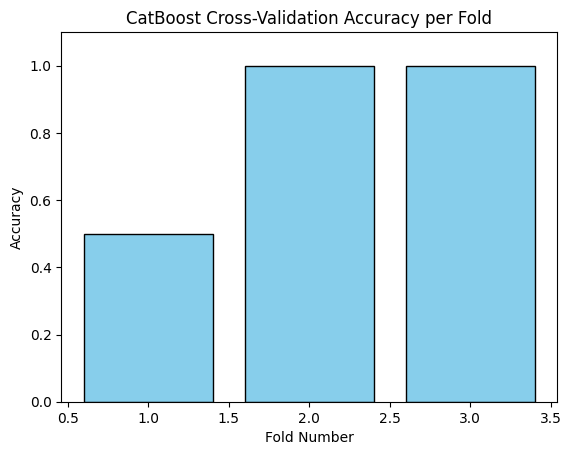

In [64]:
import matplotlib.pyplot as plt

folds = range(1, len(scores) + 1)
plt.bar(folds, scores, color='skyblue', edgecolor='black')
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("CatBoost Cross-Validation Accuracy per Fold")
plt.ylim(0, 1.1)
plt.show()


In [68]:
from sklearn.ensemble import RandomForestClassifier

models = {
    "CatBoost": CatBoostClassifier(iterations=500, verbose=0, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),

}

results = {}

for name, model in models.items():
    fold_accuracies = []
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if name == "CatBoost":
            train_pool = Pool(X_train, y_train, cat_features=cat_features)
            test_pool = Pool(X_test, y_test, cat_features=cat_features)
            model.fit(train_pool)
            acc = model.score(test_pool)
        else:
            # Encode categorical columns manually for non-CatBoost models
            X_train_enc = X_train.copy()
            X_test_enc = X_test.copy()
            X_train_enc['gender'] = X_train_enc['gender'].map({'Male': 0, 'Female': 1})
            X_test_enc['gender'] = X_test_enc['gender'].map({'Male': 0, 'Female': 1})
            model.fit(X_train_enc, y_train)
            acc = model.score(X_test_enc, y_test)
        
        fold_accuracies.append(acc)
    results[name] = fold_accuracies

# Display mean accuracies
for name, accs in results.items():
    print(f"{name} Mean CV Accuracy: {np.mean(accs):.4f}")


CatBoost Mean CV Accuracy: 0.8333
Random Forest Mean CV Accuracy: 0.6667


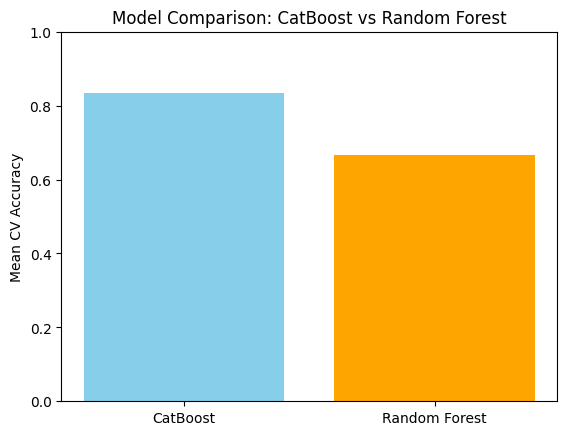

In [73]:
plt.bar(results.keys(), [np.mean(accs) for accs in results.values()],
        color=['skyblue', 'orange'])
plt.ylabel("Mean CV Accuracy")
plt.title("Model Comparison: CatBoost vs Random Forest")
plt.ylim(0, 1)
plt.show()


In [74]:
model = CatBoostClassifier(iterations=500, verbose=0, random_state=42)
model.fit(Pool(X, y, cat_features=cat_features))
feature_importance = model.get_feature_importance(prettified=True)
print(feature_importance)


       Feature Id  Importances
0   SeniorCitizen    53.510648
1  MonthlyCharges    32.326583
2          tenure     7.980538
3      customerID     4.251262
4          gender     1.930969


In [75]:
X = X.drop(columns=['customerID'])


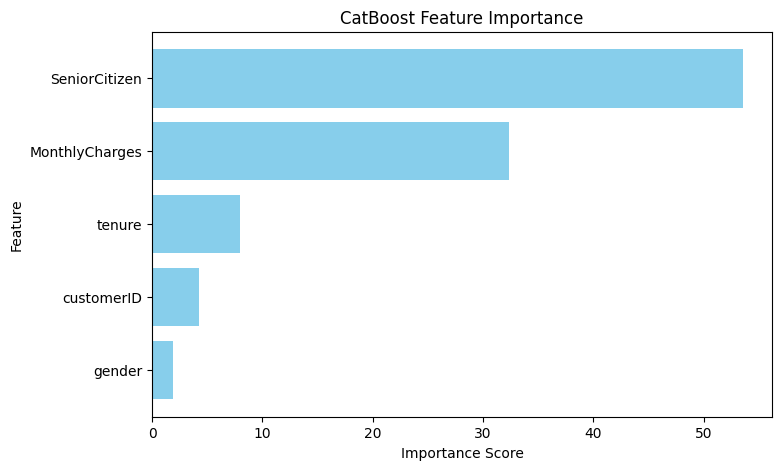

In [76]:
import matplotlib.pyplot as plt

# Assuming feature_importance is your DataFrame
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature Id'], feature_importance['Importances'], color='skyblue')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()
